Train Image Count: {'lion': 160, 'tiger': 160}
Test Image Count: {'lion': 20, 'tiger': 20}


/tmp/ipython-input-3702744988.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette='viridis')


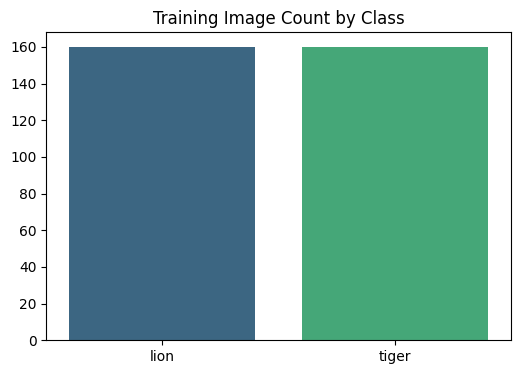

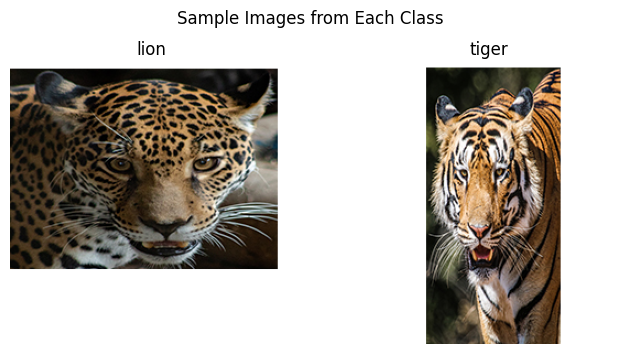

Found 320 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 431ms/step - accuracy: 0.5716 - loss: 0.7378 - val_accuracy: 0.5000 - val_loss: 0.6818
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 405ms/step - accuracy: 0.5219 - loss: 0.6825 - val_accuracy: 0.5000 - val_loss: 0.6781
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 580ms/step - accuracy: 0.5912 - loss: 0.6535 - val_accuracy: 0.4250 - val_loss: 0.6911
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 399ms/step - accuracy: 0.7104 - loss: 0.6252 - val_accuracy: 0.4500 - val_loss: 0.7338
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 500ms/step - accuracy: 0.7247 - loss: 0.5642 - val_accuracy: 0.5500 - val_loss: 0.7594
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 376ms/step - accuracy: 0.7565 - loss: 0.4919 - val_accuracy: 0.6000 - val_loss: 0.7237
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 612ms/step - accuracy: 0.8032 - loss: 0.4818 - val_accuracy: 0.5000 - val_loss: 0.7281
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 450ms/step - accuracy: 0.8439 - loss: 0.4037 - val_accuracy: 0.

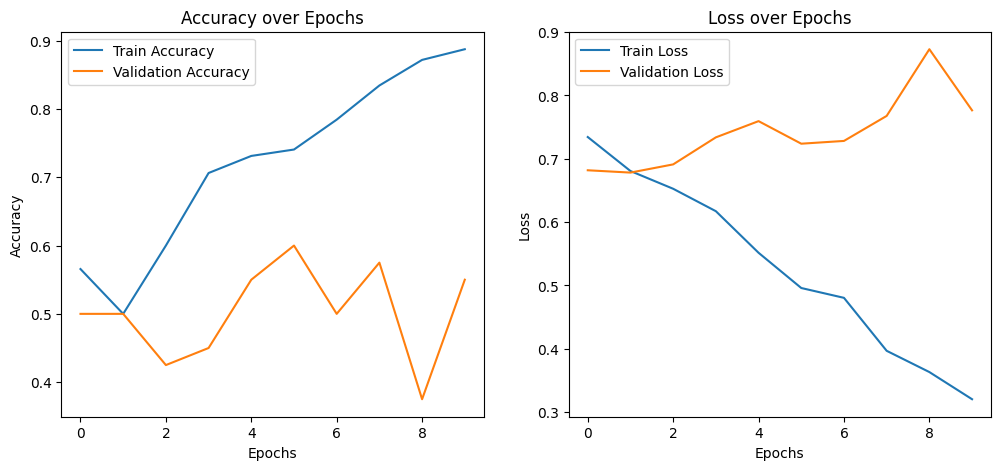


✅ Test Accuracy: 55.00%
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step


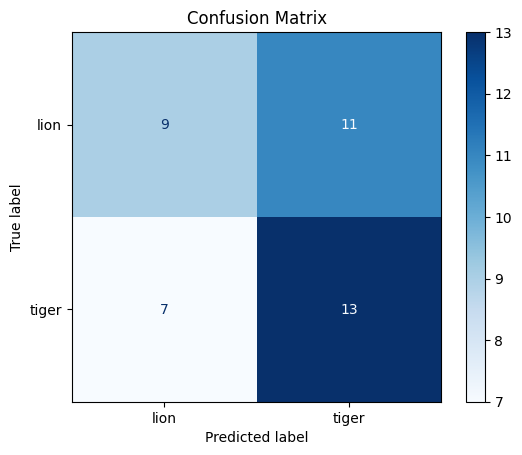

In [23]:
# ==============================
# 🦁🐯 Lion vs Tiger Classification using Simple CNN (Sequential)
# ==============================

# STEP 1: Import Required Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import Counter
import cv2
import random

# STEP 2: Define Paths
base_dir = "/content/drive/MyDrive/lion tiger"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# STEP 3: Visualize Dataset Image Count by Class
train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in os.listdir(train_dir)}
test_counts = {cls: len(os.listdir(os.path.join(test_dir, cls))) for cls in os.listdir(test_dir)}

print("Train Image Count:", train_counts)
print("Test Image Count:", test_counts)

# Bar Plot
plt.figure(figsize=(6,4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette='viridis')
plt.title("Training Image Count by Class")
plt.show()

# STEP 4: Show Some Samples of Each Class
plt.figure(figsize=(8,4))
for i, cls in enumerate(os.listdir(train_dir)):
    img_path = random.choice(os.listdir(os.path.join(train_dir, cls)))
    img = cv2.imread(os.path.join(train_dir, cls, img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.suptitle("Sample Images from Each Class")
plt.show()

# STEP 5: Data Preprocessing
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(80,80),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(80,80),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# STEP 6: Build a Simple CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(80,80,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# STEP 7: Compile the Model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# STEP 8: Train the Model (10 Epochs)
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    verbose=1
)

# STEP 9: Plot Accuracy and Loss Graphs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# STEP 10: Evaluate Model on Test Data
loss, acc = model.evaluate(test_generator, verbose=0)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

# STEP 11: Confusion Matrix Visualization
y_true = test_generator.classes
y_pred = (model.predict(test_generator) > 0.5).astype("int32").flatten()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_generator.class_indices.keys()))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


## Below code is just for experimentation purpose but the results came low so neglect it

Found 320 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
lion: 160 images
tiger: 160 images


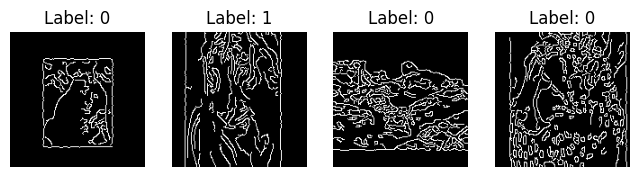

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5235 - loss: 1.7307 - val_accuracy: 0.5000 - val_loss: 0.7550
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5616 - loss: 0.6672 - val_accuracy: 0.5250 - val_loss: 0.6961
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8271 - loss: 0.6379 - val_accuracy: 0.4500 - val_loss: 0.7087
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8772 - loss: 0.5080 - val_accuracy: 0.4750 - val_loss: 0.8016
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9094 - loss: 0.3208 - val_accuracy: 0.4750 - val_loss: 1.1155
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9791 - loss: 0.1732 - val_accuracy: 0.4250 - val_loss: 1.1661
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9988 - loss: 0.0538 - val_accuracy: 0.4500 - val_loss: 1.4414
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9988 - loss: 0.0218 - val_accuracy: 0.4250 - val_loss:

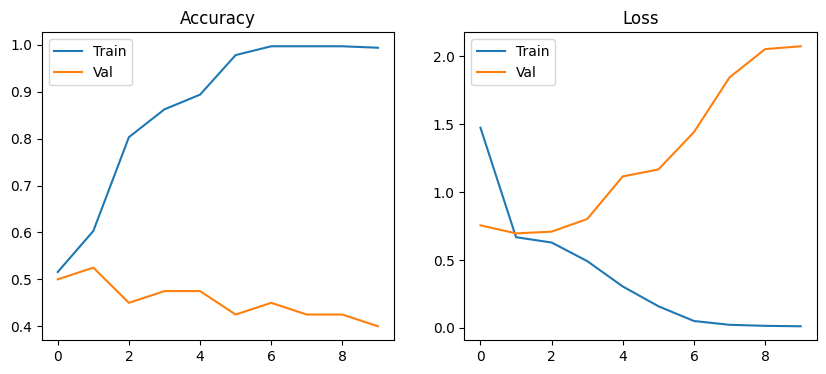

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step


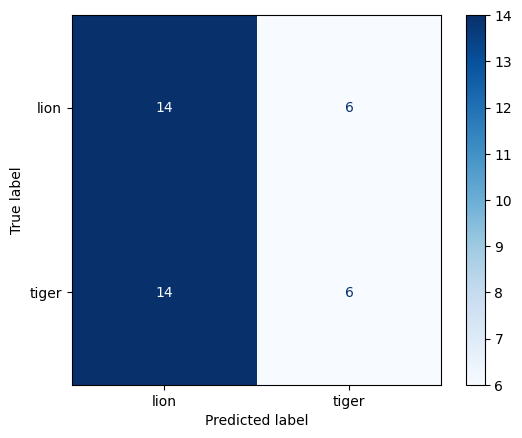

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.3812 - loss: 2.1227
✅ Test Accuracy: 40.00%


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2

# STEP 1: Paths
train_dir = '/content/drive/MyDrive/lion tiger/train'  # update paths
test_dir = '/content/drive/MyDrive/lion tiger/test'

# STEP 2: Data visualization setup
train_datagen = ImageDataGenerator(preprocessing_function=lambda x: edge_preprocess(x), rescale=1./255)
test_datagen = ImageDataGenerator(preprocessing_function=lambda x: edge_preprocess(x), rescale=1./255)

# ---- FIXED FUNCTION ----
def edge_preprocess(img):
    img = img.astype('uint8')          # ensure correct type for OpenCV
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 100, 200)
    edges_rgb = np.stack((edges,)*3, axis=-1)  # make 3-channel
    edges_rgb = edges_rgb.astype('float32')    # <-- FIX: convert to float32 before returning
    return edges_rgb

# STEP 3: Data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# STEP 4: Visualize dataset info
for label, idx in train_generator.class_indices.items():
    print(f"{label}: {len(os.listdir(os.path.join(train_dir, label)))} images")

# STEP 5: Show sample images
x_batch, y_batch = next(train_generator)
plt.figure(figsize=(8, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_batch[i])
    plt.title(f"Label: {int(y_batch[i])}")
    plt.axis("off")
plt.show()

# STEP 6: Model definition
model = Sequential([
    tf.keras.Input(shape=(150, 150, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# STEP 7: Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

# STEP 8: Plot training accuracy/loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

# STEP 9: Confusion matrix
y_true = test_generator.classes
y_pred = (model.predict(test_generator) > 0.5).astype("int32")
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap='Blues')
plt.show()

# STEP 10: Final test accuracy
loss, acc = model.evaluate(test_generator)
print(f"✅ Test Accuracy: {acc*100:.2f}%")
